<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Datasets_distribution_in_classification_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Handling Imbalanced Data for Classification**

Imbalanced data occurs when one class has far more samples than others, causing models to favour the majority class and perform poorly on the minority class. This often results in misleading accuracy, especially in critical applications like fraud detection or medical diagnosis.

- ML models tend to get biased toward the majority class and predict it more frequently.

- Minority class instances may be treated as noise, causing the model to overlook them.

- Accuracy becomes misleading because the model performs well only on the dominant class.

- Skewed decision boundaries lead to poor generalisation and weak performance on minority class predictions.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

sns.set(style="whitegrid", palette="Set2")

In [11]:
data = load_iris()
X = data.data
y = data.target

In [8]:
print(f"Class distribution in full dataset: {Counter(y)}")

Class distribution in full dataset: Counter({np.int64(0): 50, np.int64(1): 50, np.int64(2): 50})


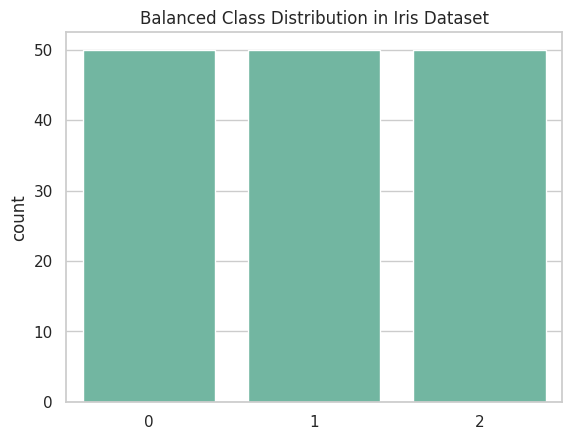

In [10]:
sns.countplot(x=y)
plt.title("Balanced Class Distribution in Iris Dataset")
plt.show()

# Splitting Data - With & Without Stratification

Stratification ensures that the train and test sets preserve the original dataset’s class distribution.

In [14]:
# Without stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train distribution (no stratify):", Counter(y_train))
print("Test distribution (no stratify):", Counter(y_test))

Train distribution (no stratify): Counter({np.int64(1): 37, np.int64(2): 37, np.int64(0): 31})
Test distribution (no stratify): Counter({np.int64(0): 19, np.int64(1): 13, np.int64(2): 13})


In [15]:
# With stratify
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print("Train distribution (stratify):", Counter(y_train_s))
print("Test distribution (stratify):", Counter(y_test_s))

Train distribution (stratify): Counter({np.int64(1): 35, np.int64(0): 35, np.int64(2): 35})
Test distribution (stratify): Counter({np.int64(2): 15, np.int64(1): 15, np.int64(0): 15})


### Key Takeaway: Always use `stratify=y`.

`Whenever we split data for classification, we should always stratify on labels to keep the same class distribution in train and test sets.`



---



In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/imbalanced_dataset.csv')

In [19]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
0,1.108936,1.540492,0.493516,-0.529740,0.982175,1.177544,1.623025,1.357325,0.966041,-0.504924,0
1,-0.564641,3.638629,-1.522415,-1.541705,1.616697,4.781310,3.190292,-0.890254,1.438826,-3.828748,0
2,0.516313,2.165426,-0.628486,-0.386923,0.492518,1.442381,1.332905,-1.958175,-0.348803,-1.804124,0
3,1.476534,0.548523,-0.115420,-0.875408,1.301216,0.410295,1.171878,-1.034471,-1.654176,1.344601,0
4,0.278385,1.065828,-1.724917,-2.235667,0.715107,0.731249,-0.674119,0.598330,-0.524283,1.047610,0


In [20]:
df['Target'].value_counts()

,count
Target,
0,896
1,104


This will show how many samples belong to each class.

**If you want percentages too:**

In [24]:
print(df['Target'].value_counts(normalize=True) * 100)

Target
0    89.6
1    10.4
Name: proportion, dtype: float64


In [26]:
# OR using groupby
print(df.groupby('Target').size())

Target
0    896
1    104
dtype: int64


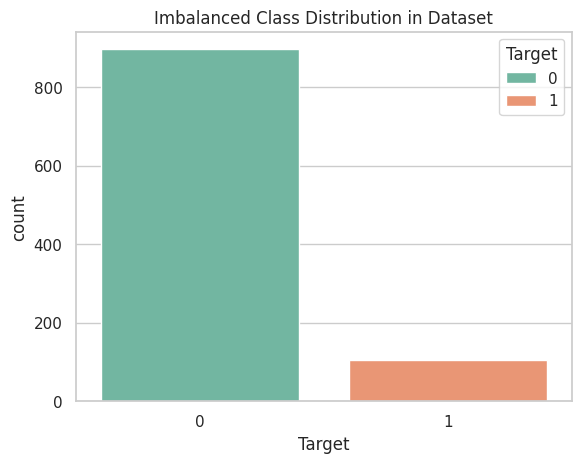

In [29]:
sns.countplot(x=df['Target'], hue=df['Target'])
plt.title("Imbalanced Class Distribution in Dataset")
plt.show()

# or using matplotlib

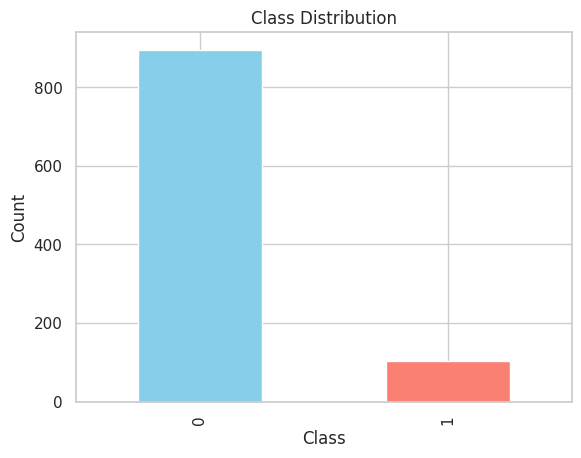

In [27]:
import matplotlib.pyplot as plt

df['Target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [30]:
df.head()

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Target
0,1.108936,1.540492,0.493516,-0.529740,0.982175,1.177544,1.623025,1.357325,0.966041,-0.504924,0
1,-0.564641,3.638629,-1.522415,-1.541705,1.616697,4.781310,3.190292,-0.890254,1.438826,-3.828748,0
2,0.516313,2.165426,-0.628486,-0.386923,0.492518,1.442381,1.332905,-1.958175,-0.348803,-1.804124,0
3,1.476534,0.548523,-0.115420,-0.875408,1.301216,0.410295,1.171878,-1.034471,-1.654176,1.344601,0
4,0.278385,1.065828,-1.724917,-2.235667,0.715107,0.731249,-0.674119,0.598330,-0.524283,1.047610,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_0  1000 non-null   float64
 1   Feature_1  1000 non-null   float64
 2   Feature_2  1000 non-null   float64
 3   Feature_3  1000 non-null   float64
 4   Feature_4  1000 non-null   float64
 5   Feature_5  1000 non-null   float64
 6   Feature_6  1000 non-null   float64
 7   Feature_7  1000 non-null   float64
 8   Feature_8  1000 non-null   float64
 9   Feature_9  1000 non-null   float64
 10  Target     1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [33]:
# Separate Features and Target

X = df.drop('Target', axis=1)
y = df['Target']

In [37]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({0: 717, 1: 83})
Test distribution: Counter({0: 179, 1: 21})


In [38]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({0: 717, 1: 83})
Test distribution: Counter({0: 179, 1: 21})


#  **Fixing Imbalance**

<img src="https://www.lifewire.com/thmb/WaLJWEH-k6sxobSB3KmHffS17rI=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc():format(webp)/rocks-balancing-on-driftwood--sea-in-background-153081592-591bbc3f5f9b58f4c0b7bb16.jpg" width=512, height=128>

**(a) Random Oversampling**

Random Oversampling is a data preprocessing technique used in machine learning to balance imbalanced datasets by randomly duplicating examples from the minority class

> Duplicates minority class samples.



In [39]:
ros = RandomOverSampler()
X_resampled, y_resampled = ros.fit_resample(X, y)
print("Resampled dataset shape:", Counter(y_resampled))

Resampled dataset shape: Counter({0: 896, 1: 896})


After Oversampling: Counter({0: 896, 1: 896})


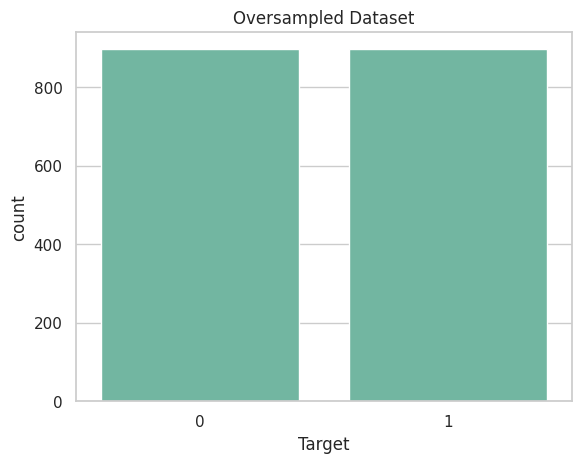

In [41]:
print("After Oversampling:", Counter(y_resampled))
sns.countplot(x=y_resampled)
plt.title("Oversampled Dataset")
plt.show()

In [55]:
X_resampled.duplicated().sum()

np.int64(792)

**Note:** High Risk of Overfitting

**(b) Random Undersampling**

Random undersampling is a data preprocessing technique that balances an imbalanced dataset by randomly deleting examples from the majority class.


> Drops samples from majority class.

Learn More: (https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)



After Undersampling: Counter({0: 104, 1: 104})


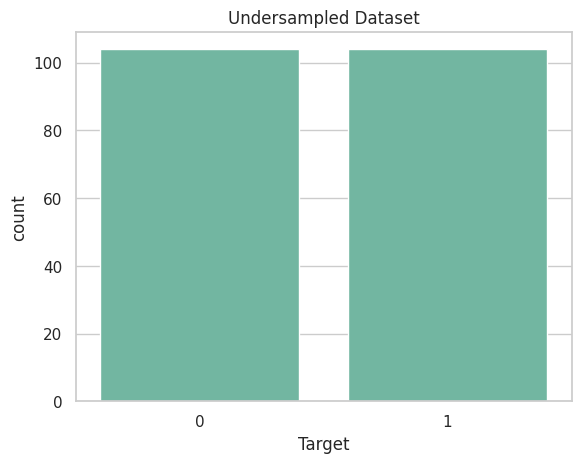

In [44]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

print("After Undersampling:", Counter(y_rus))
sns.countplot(x=y_rus)
plt.title("Undersampled Dataset")
plt.show()



---





---





---



# (c). SMOTE (Synthetic Minority Oversampling Technique)


**SMOTE** (Synthetic Minority Over-sampling Technique) is a data-balancing method used in machine learning to **fix imbalanced datasets by generating artificial points for the minority class**.



> generates new synthetic minority samples → better than just copying.







After SMOTE: Counter({0: 896, 1: 896})


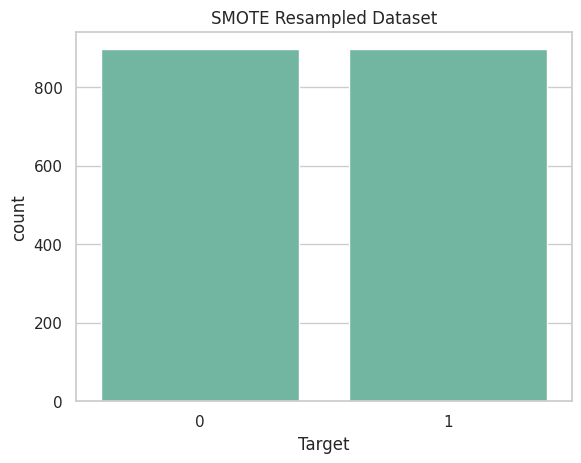

In [47]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

print("After SMOTE:", Counter(y_smote))
sns.countplot(x=y_smote)
plt.title("SMOTE Resampled Dataset")
plt.show()

**Example:** If you have two minority samples close together, SMOTE generates a new sample in between.

In [54]:
X_smote.duplicated().sum()

np.int64(0)

**Conclusion**

Imbalanced datasets are common in the real world from fraud detection to healthcare. If left untreated, they can make models look accurate but fail in practice.

**We learned how to:**

- Detect imbalance
- Apply oversampling, undersampling, and SMOTE
- Evaluate models beyond accuracy
- By following these principles, you’ll build robust classifiers that actually work in critical scenarios.



---



# References

- Learn More: https://blog.devgenius.io/understanding-and-handling-imbalanced-datasets-in-classification-models-bb10ac6fa1a7

- Also do Check this colab notebok: https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/dataset_distribution_in_classification_models.ipynb#scrollTo=fEpIWa-HkCIU

- https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/